In [1]:
import numpy as np
import pandas as pd
import random

from sklearn import ensemble
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, auc, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning. 

import lightgbm as lgb
from lightgbm import LGBMClassifier

In [2]:
# load test data
X_test = pd.read_parquet("../data/model_raw/X_test.parquet")
y_test = pd.read_parquet("../data/model_raw/Y_test.parquet")['depression_severity']
X_test = np.array(X_test)
y_test = np.array(np.where(y_test > 0, 1, 0)) # np array of binary labels

# load models
lr = joblib.load("./model_files/logistic_best_model.pkl")
lgbm = joblib.load("./model_files/lightgbm_best_model.pkl")
rf = joblib.load("./model_files/random_forest_best_model.pkl")
xgb = joblib.load("./model_files/XGB_best_model.pkl")


### baseline guessing based on the distribution of the raw training dataset
y_train_raw = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw['dep_bin'] = np.where(y_train_raw['depression_severity'] > 0, 1, 0)
y_test = pd.read_parquet("../data/model_raw/Y_test.parquet")['depression_severity']
y_test = np.array(np.where(y_test > 0, 1, 0)) # np array of binary labels

counts = pd.DataFrame(y_train_raw['dep_bin'].value_counts()).reset_index()

guess_0 = counts[counts['dep_bin'] == 0]['count']/counts['count'].sum()
guess_1 = counts[counts['dep_bin'] == 1]['count'] / counts['count'].sum()

ones = np.ones(round(len(y_test) * guess_1).astype(int))
zeros = np.zeros(round(len(y_test) * guess_0).astype(int))

# concatenate 1 and 0 guesses
out = np.concatenate((ones, zeros))
random_df = pd.DataFrame(out, columns=['pred'])

# shuffle 1 and 0 guesses randomly
np.random.seed(12345)
indices = random_df.index.tolist()
shuffled_indices = np.random.permutation(indices)
baseline_preds = random_df.reindex(shuffled_indices).reset_index(drop=True)

# probability of positive class in training data
baseline_prob = guess_1.values[0]

# constant probability predictions
baseline_probs = np.full(len(y_test), baseline_prob)

2026-04-16 18:51:11.471312: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-16 18:51:11.471341: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-04-16 18:51:11.471345: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2026-04-16 18:51:11.471358: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-16 18:51:11.471368: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
# model probabilities (positive class = 1)
lr_probs = lr.model.predict(X_test).ravel()
lgbm_probs = lgbm.predict_proba(X_test)[:, 1]
rf_probs= rf.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

2026-04-16 18:51:11.668301: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [4]:
# compute ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
base_fpr, base_tpr, _ = roc_curve(y_test, baseline_probs)

# compute AUC
lr_auc = auc(lr_fpr, lr_tpr)
lgbm_auc = auc(lgbm_fpr, lgbm_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)
base_auc = auc(base_fpr, base_tpr)

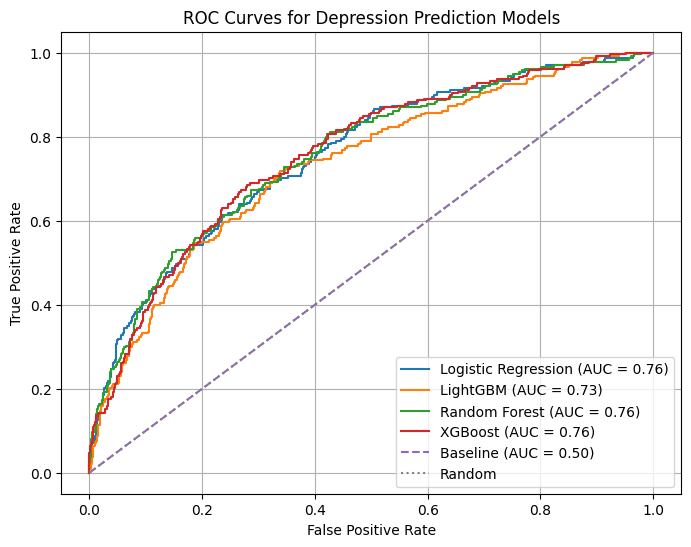

In [5]:
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")
plt.plot(lgbm_fpr, lgbm_tpr, label=f"LightGBM (AUC = {lgbm_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")

# baseline
plt.plot(base_fpr, base_tpr, linestyle='--', label=f"Baseline (AUC = {base_auc:.2f})")

# random guess line 
plt.plot([0,1], [0,1], linestyle=':', color='gray', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Depression Prediction Models")
plt.legend()
plt.grid()

plt.show()

In [6]:
# accuracies
# threshold at 0.5
lr_pred = (lr_probs >= 0.5).astype(int)
lgbm_pred = (lgbm_probs >= 0.5).astype(int)
rf_pred = (rf_probs >= 0.5).astype(int)
xgb_pred = (xgb_probs >= 0.5).astype(int)

# baseline (constant probability → predictions)
baseline_pred = (baseline_probs >= 0.5).astype(int)

from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)
lgbm_acc = accuracy_score(y_test, lgbm_pred)
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)
base_acc = accuracy_score(y_test, baseline_pred)

print(f"Logistic Regression Accuracy: {lr_acc:.3f}")
print(f"LightGBM Accuracy: {lgbm_acc:.3f}")
print(f"Random Forest Accuracy: {rf_acc:.3f}")
print(f"XGBoost Accuracy: {xgb_acc:.3f}")
print(f"Baseline Accuracy: {base_acc:.3f}")

Logistic Regression Accuracy: 0.697
LightGBM Accuracy: 0.761
Random Forest Accuracy: 0.730
XGBoost Accuracy: 0.702
Baseline Accuracy: 0.765
